In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Data Analysis

In [5]:
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

In [6]:
train_input = pd.read_csv("Credit_Risk_Train_Data.csv")
validate_input = pd.read_csv("Credit_Risk_Validate_Data.csv")

In [7]:
train_input.isnull()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False,False,False,False,False,False,False
610,False,False,False,False,False,False,False,False,False,False,False,False,False
611,False,False,False,False,False,False,False,False,False,False,False,False,False
612,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
print(train_input.columns)
print(validate_input.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'outcome'],
      dtype='object')


In [9]:
# the last column has a diffrent name in both,
# Lets make the same, and then merge them together
# so that we can fill the missing values simultenously

validate_input.rename(columns={"outcome":"Loan_Status"}, inplace = True)

In [10]:
# Concat only works when the name and number of columns matches

data_all = pd.concat([train_input, validate_input], ignore_index=True)
data_all.shape

(981, 13)

In [11]:
data_all.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
976,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,Y
977,LP002975,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,Y
978,LP002980,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,Y
979,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,N
980,LP002989,Male,No,0,Graduate,Yes,9200,0.0,98.0,180.0,1.0,Rural,Y


### Missing value Processing

<Axes: >

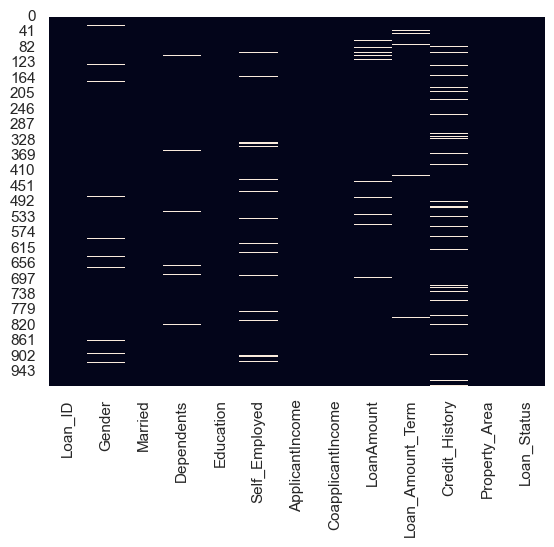

In [12]:
plt.figure(figure=(20,10))
sns.heatmap(data_all.isnull(), cbar=False)

In [13]:
data_all.isnull().sum() # gives the missing values of all columns

Loan_ID               0
Gender               24
Married               3
Dependents           25
Education             0
Self_Employed        55
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
Property_Area         0
Loan_Status           0
dtype: int64

### NaN Fill with Mode

In [14]:
Counter(data_all["Gender"])

Counter({'Male': 775, 'Female': 182, nan: 24})

In [15]:
data_all.fillna({'Gender':'Male'}, inplace =True)

In [16]:
# check if filled
Counter(data_all["Gender"])

Counter({'Male': 799, 'Female': 182})

In [17]:
# lets fill Married now
print(Counter(data_all["Married"]))

Counter({'Yes': 631, 'No': 347, nan: 3})


In [18]:
data_all.fillna({'Married':'Yes'}, inplace=True)

In [19]:
data_all.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           25
Education             0
Self_Employed        55
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
Property_Area         0
Loan_Status           0
dtype: int64

### NaN fill with Cross Tab

In [20]:
Counter(data_all['Dependents'])

Counter({'0': 545, '1': 160, '2': 160, '3+': 91, nan: 25})

In [21]:
#Lets see the Dependents w.r.t Marriage
pd.crosstab(data_all['Married'], data_all['Dependents'].isnull())

Dependents,False,True
Married,,
No,338,9
Yes,618,16


In [22]:
pd.crosstab(data_all['Dependents'], data_all['Married'])

Married,No,Yes
Dependents,,
0,276,269
1,36,124
2,14,146
3+,12,79


In [23]:
# for the batchelors, lets fill the missing dependents as 0
#lets find the index of all rows with Dependents missing and Married NO
bachelors_nulldependents = data_all[(data_all["Married"]=='No') &
                                    (data_all["Dependents"].isnull())].index.tolist()
print(bachelors_nulldependents)

[293, 332, 355, 597, 684, 752, 879, 916, 926]


In [24]:
data_all['Dependents'].iloc[bachelors_nulldependents]='0'

In [25]:
Counter(data_all['Dependents'])

Counter({'0': 554, '1': 160, '2': 160, '3+': 91, nan: 16})

In [26]:
# for the remaining 16 is missing dependents,
#lets see how many dependents 'Male' & 'Female' have
pd.crosstab(data_all['Gender'], data_all['Dependents'])

Dependents,0,1,2,3+
Gender,,,,
Female,127,32,13,9
Male,427,128,147,82


In [27]:
#Lets see the gender of the 16 missing dependents
pd.crosstab(data_all['Gender'], data_all['Dependents'].isnull())

Dependents,False,True
Gender,,
Female,181,1
Male,784,15


In [28]:
pd.crosstab((data_all['Gender']=='Male') &
           (data_all['Married']=='Yes'),
           data_all['Dependents'])

Dependents,0,1,2,3+
row_0,,,,
False,318,48,23,15
True,236,112,137,76


In [29]:
#lets fill the dependents with 1
data_all['Dependents'].iloc[data_all[data_all['Dependents'].isnull()].index.tolist()]="1"

In [30]:
data_all.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        55
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
Property_Area         0
Loan_Status           0
dtype: int64

In [31]:
Counter(data_all['Self_Employed'])

Counter({'No': 807, 'Yes': 119, nan: 55})

In [32]:
data_all.fillna({'Self_Employed':'No'}, inplace = True)

In [33]:
data_all.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
Property_Area         0
Loan_Status           0
dtype: int64

# Machine Learning

### NaN fill with Mean

In [34]:
# To check if any row with both LoanAmount and Loan_Amount_Term as NaN
pd.crosstab(data_all['LoanAmount'].isnull(),
           data_all['Loan_Amount_Term'].isnull())

Loan_Amount_Term,False,True
LoanAmount,,
False,934,20
True,27,0


In [35]:
pd.crosstab(data_all['LoanAmount'].isnull(),
           data_all['Loan_Amount_Term'])

Loan_Amount_Term,6.0,12.0,36.0,60.0,84.0,120.0,180.0,240.0,300.0,350.0,360.0,480.0
LoanAmount,,,,,,,,,,,,
False,1,2,3,3,7,4,64,7,20,1,800,22
True,0,0,0,0,0,0,2,1,0,0,23,1


In [36]:
data_all.groupby(data_all['Loan_Amount_Term'])['LoanAmount'].mean()

Loan_Amount_Term
6.0       95.000000
12.0     185.500000
36.0     117.666667
60.0     139.666667
84.0     121.142857
120.0     36.750000
180.0    131.125000
240.0    128.857143
300.0    166.250000
350.0    133.000000
360.0    144.420000
480.0    137.181818
Name: LoanAmount, dtype: float64

In [37]:
#Lets ffill the mising values in Loan Amount
# with the mean of the respective Loan Term
# we see that 180 and 240 has almost the same loan amount 128-131
# and 360 has hihj i.e 144
# and all remaining has 131
data_all['LoanAmount'][(data_all['LoanAmount'].isnull())
                        & (data_all['Loan_Amount_Term']==360)]=144
data_all['LoanAmount'][(data_all['LoanAmount'].isnull())
                        & (data_all['Loan_Amount_Term']==480)]=137

In [38]:
data_all['LoanAmount'][(data_all['LoanAmount'].isnull())]=130

In [39]:
#lets fill Loan Amount Term
(data_all['Loan_Amount_Term']).value_counts()

Loan_Amount_Term
360.0    823
180.0     66
480.0     23
300.0     20
240.0      8
84.0       7
120.0      4
60.0       3
36.0       3
12.0       2
350.0      1
6.0        1
Name: count, dtype: int64

In [40]:
#Lets fill the loan Tenure by the mode i.e 360
data_all['Loan_Amount_Term'][data_all['Loan_Amount_Term'].isnull()] = 360

In [41]:
data_all.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       79
Property_Area         0
Loan_Status           0
dtype: int64

In [42]:
data_all['Credit_History'].value_counts()

Credit_History
1.0    754
0.0    148
Name: count, dtype: int64

In [43]:
# Gender makes no diffrence
pd.crosstab(data_all['Gender'],data_all['Credit_History'])

Credit_History,0.0,1.0
Gender,,
Female,30,135
Male,118,619


In [44]:
#Self  Employed makes no diffrence
pd.crosstab(data_all['Self_Employed'],data_all['Credit_History'])

Credit_History,0.0,1.0
Self_Employed,,
No,134,658
Yes,14,96


In [45]:
# Eductaion makes no diffrence
pd.crosstab(data_all['Education'],data_all['Credit_History'])

Credit_History,0.0,1.0
Education,,
Graduate,106,596
Not Graduate,42,158


In [46]:
# Married makes no diffrence
pd.crosstab(data_all['Married'],data_all['Credit_History'])

Credit_History,0.0,1.0
Married,,
No,56,263
Yes,92,491


In [47]:
data_all.fillna({'Credit_History':1.0}, inplace = True)

In [48]:
data_all.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Categorical Feature Engineering

In [49]:
data_all.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,144.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [50]:
data_all['Dependents'].value_counts()

Dependents
0     554
1     176
2     160
3+     91
Name: count, dtype: int64

In [51]:
data_all['Dependents'][data_all['Dependents']=='3+']='3'

In [52]:
data_all['Dependents'].head()

0    0
1    1
2    0
3    0
4    0
Name: Dependents, dtype: object

In [53]:
data_all['Dependents']=data_all['Dependents'].astype(int)
data_all['Dependents'].head()

0    0
1    1
2    0
3    0
4    0
Name: Dependents, dtype: int32

In [54]:
data_all_new = pd.get_dummies(data_all.drop(['Loan_ID'], axis=1),drop_first=True)
data_all_new = data_all_new*1

In [55]:
data_all_new.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,0,5849,0.0,144.0,360.0,1.0,1,0,0,0,0,1,1
1,1,4583,1508.0,128.0,360.0,1.0,1,1,0,0,0,0,0
2,0,3000,0.0,66.0,360.0,1.0,1,1,0,1,0,1,1
3,0,2583,2358.0,120.0,360.0,1.0,1,1,1,0,0,1,1
4,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1,1


In [56]:
X=data_all_new.drop(['Loan_Status_Y'], axis=1)
y=data_all_new['Loan_Status_Y']

In [57]:
X.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,144.0,360.0,1.0,1,0,0,0,0,1
1,1,4583,1508.0,128.0,360.0,1.0,1,1,0,0,0,0
2,0,3000,0.0,66.0,360.0,1.0,1,1,0,1,0,1
3,0,2583,2358.0,120.0,360.0,1.0,1,1,1,0,0,1
4,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1


In [58]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status_Y, dtype: int32

### Data Splitting

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [61]:
X_train.shape

(735, 12)

In [62]:
X_test.shape

(246, 12)

### Feature Scaling

In [63]:
from sklearn.preprocessing import StandardScaler

In [64]:
scaler=StandardScaler()

In [65]:
#Fit only to training data
scaler.fit(X)

StandardScaler()

In [66]:
#now apply the transformation to data:
X_trian=scaler.transform(X_train)
X_test=scaler.transform(X_test)

In [67]:
X_trian[:5]

array([[ 0.2106796 , -0.52102782, -0.07504134, -0.75351389,  0.2705276 ,
         0.42151046,  0.47726799,  0.73980985, -0.53452248, -0.37155221,
        -0.74311183,  1.36690199],
       [ 1.18556961,  0.38125935,  0.89316829,  0.55688697, -2.52237248,
         0.42151046,  0.47726799,  0.73980985, -0.53452248, -0.37155221,
        -0.74311183,  1.36690199],
       [-0.76421042, -0.43248562, -0.5895062 , -0.95007402,  0.2705276 ,
         0.42151046,  0.47726799, -1.35169869, -0.53452248, -0.37155221,
         1.34569248, -0.73158135],
       [ 1.18556961, -0.0242077 ,  0.17703909,  0.55688697,  0.2705276 ,
         0.42151046,  0.47726799,  0.73980985, -0.53452248, -0.37155221,
        -0.74311183, -0.73158135],
       [-0.76421042,  0.91989106, -0.5895062 ,  0.58309499,  0.2705276 ,
        -2.37242036,  0.47726799, -1.35169869, -0.53452248,  2.6914118 ,
        -0.74311183,  1.36690199]])

### Training model using K-nn

In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
from sklearn.neighbors import KNeighborsClassifier

In [70]:
parameters={'n_neighbors':[3,5,11,19],
           'weights':['uniform','distance'],
           'metric':['minikowski','manhattan']}

In [71]:
clf=GridSearchCV(KNeighborsClassifier(), parameters, cv=3, verbose=1, n_jobs=-1)

In [72]:
clf.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['minikowski', 'manhattan'],
                         'n_neighbors': [3, 5, 11, 19],
                         'weights': ['uniform', 'distance']},
             verbose=1)

In [73]:
clf.best_score_

0.7224489795918366

In [74]:
clf.best_params_

{'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}

In [75]:
clf=KNeighborsClassifier(metric='manhattan', n_neighbors=11,weights='distance')
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [76]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [77]:
confusion_matrix(y_test, y_pred)

array([[  0,  64],
       [  0, 182]], dtype=int64)

In [78]:
accuracy_score(y_test,y_pred)

0.7398373983739838

In [79]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        64
           1       0.74      1.00      0.85       182

    accuracy                           0.74       246
   macro avg       0.37      0.50      0.43       246
weighted avg       0.55      0.74      0.63       246

